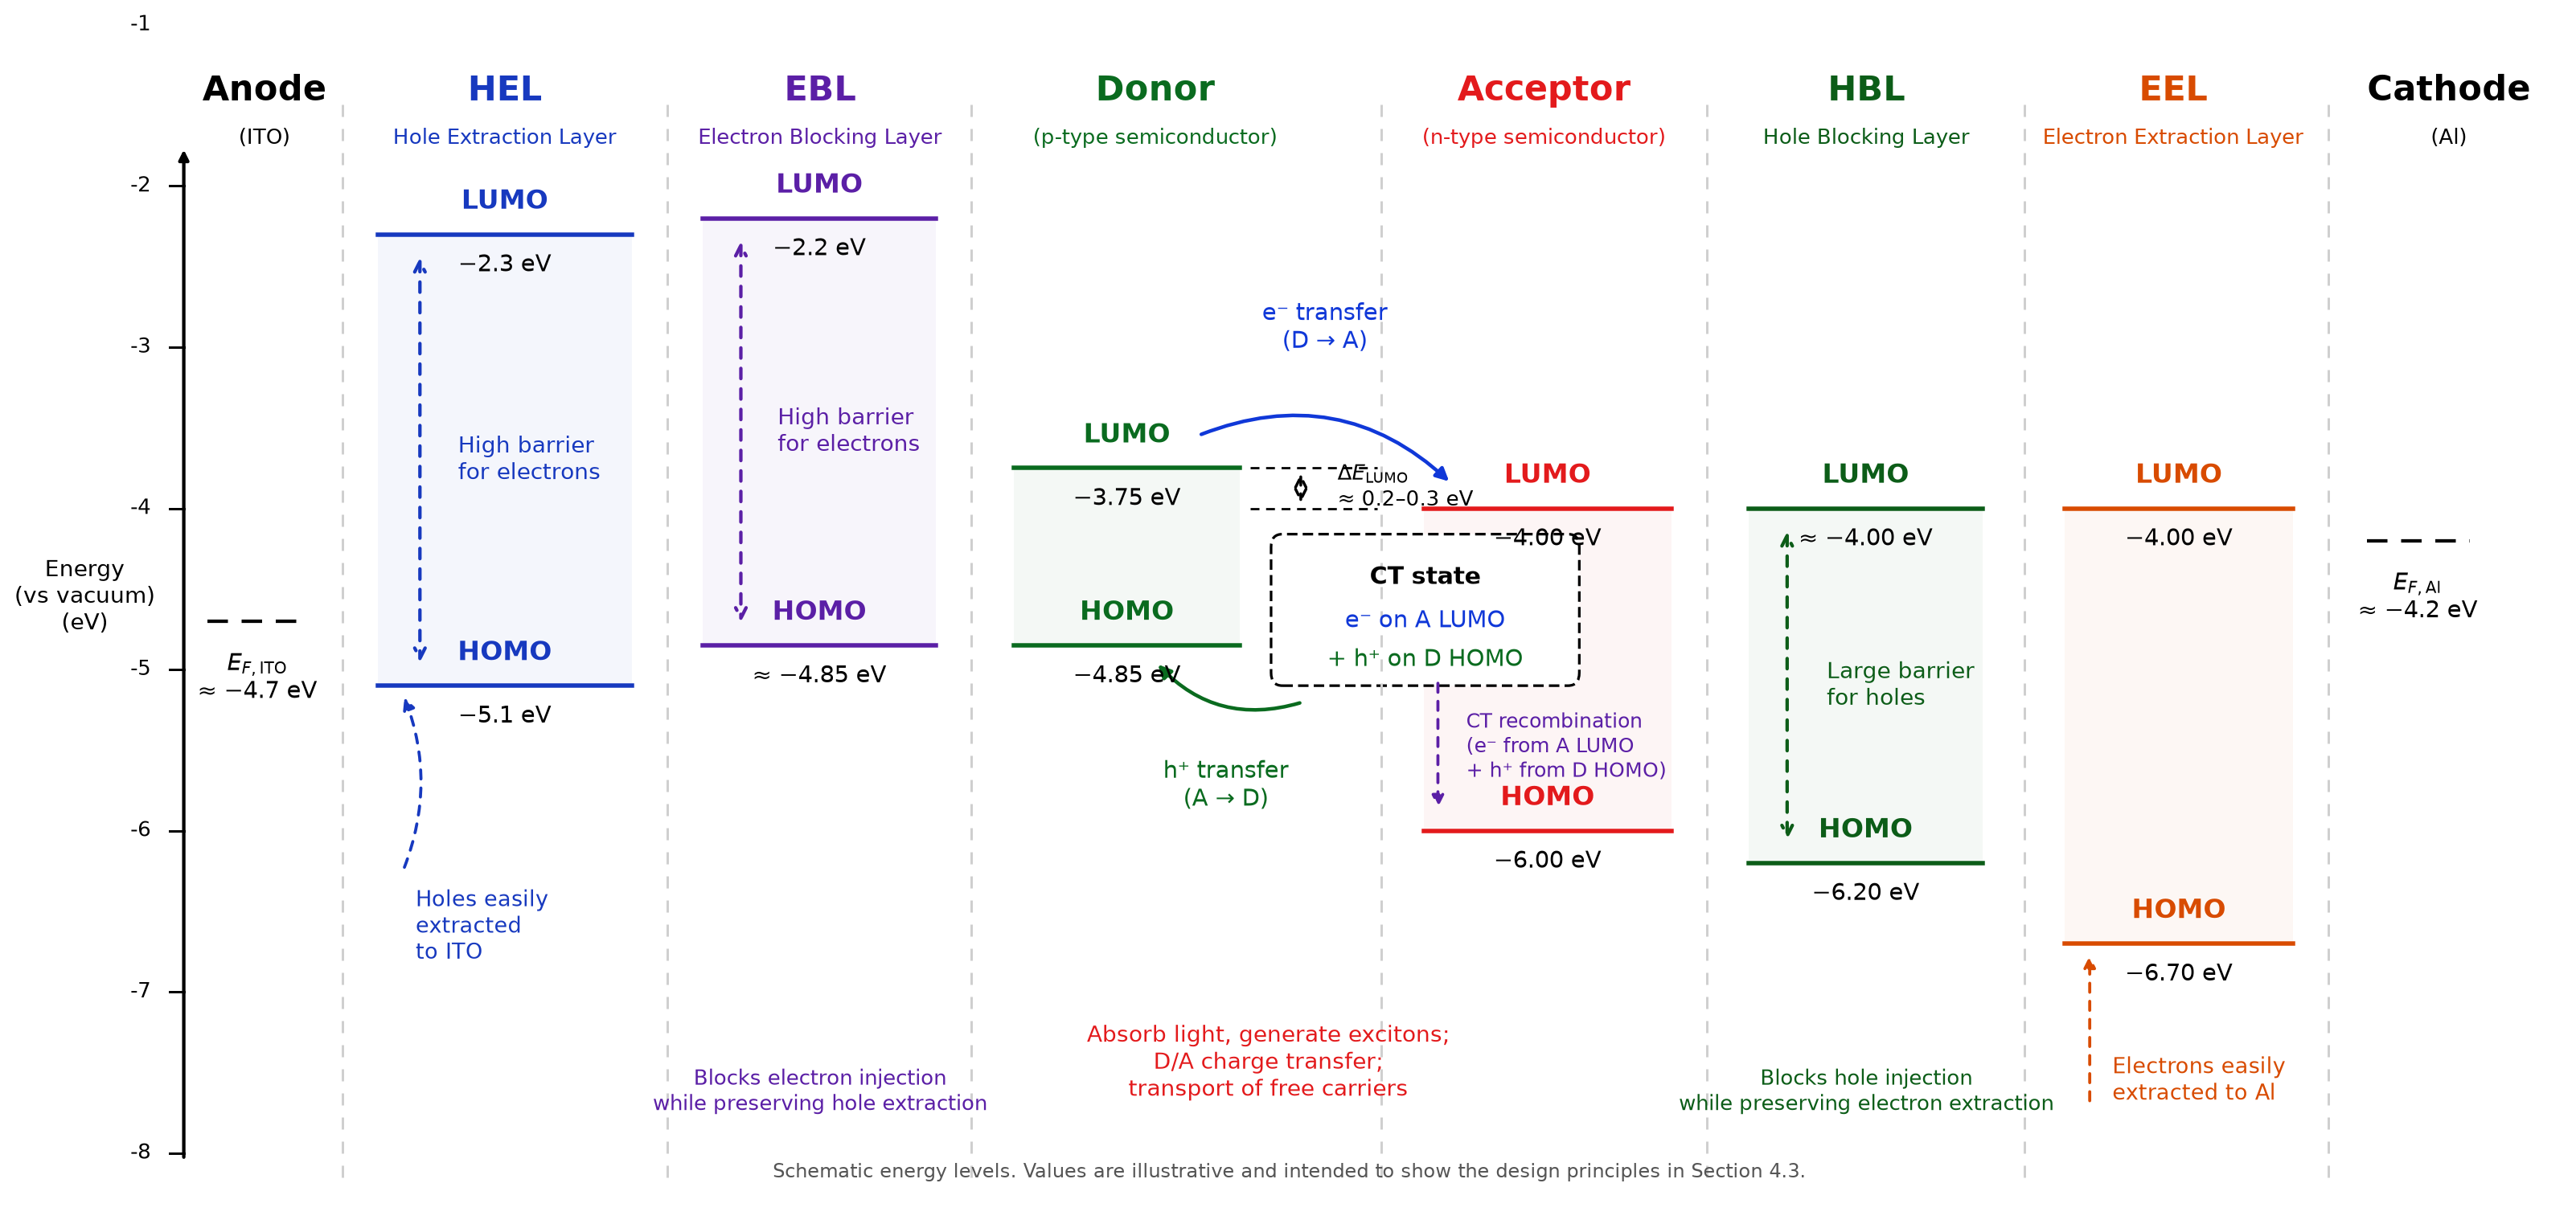

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch, FancyBboxPatch, Arc
from matplotlib.lines import Line2D

# ---------------------------
# Figure and global settings
# ---------------------------
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["mathtext.fontset"] = "dejavusans"

fig, ax = plt.subplots(figsize=(18, 8.5), dpi=180)
ax.set_xlim(0, 18)
ax.set_ylim(-8.35, -1.35)
ax.axis("off")

# ---------------------------
# Helpers
# ---------------------------
def level(x0, x1, y, color, label, value=None, lw=2.2, alpha_fill=0.045, y_other=None):
    """Draw an energy level line and optional light fill to another level."""
    ax.plot([x0, x1], [y, y], color=color, lw=lw)
    ax.text((x0+x1)/2, y+0.12, label, ha="center", va="bottom",
            fontsize=13, color=color, fontweight="bold")
    if value is not None:
        ax.text((x0+x1)/2, y-0.12, value, ha="center", va="top",
                fontsize=11.5, color="black")
    if y_other is not None:
        y_low, y_high = sorted([y, y_other])
        ax.add_patch(Rectangle((x0, y_low), x1-x0, y_high-y_low,
                               facecolor=color, edgecolor="none", alpha=alpha_fill, zorder=0))

def dashed_separator(x):
    ax.plot([x, x], [-8.15, -1.45], color="#cfcfcf", lw=1.2, ls=(0, (5, 5)))

def top_title(x, title, subtitle=None, color="black"):
    ax.text(x, -1.52, title, ha="center", va="bottom",
            fontsize=17, fontweight="bold", color=color)
    if subtitle:
        ax.text(x, -1.77, subtitle, ha="center", va="bottom",
                fontsize=10.5, color=color)

def v_arrow(x, y0, y1, color, text=None, text_x=None, ls=(0, (3, 3)), lw=1.7):
    arrow = FancyArrowPatch((x, y0), (x, y1),
                            arrowstyle="<->", mutation_scale=13,
                            lw=lw, linestyle=ls, color=color)
    ax.add_patch(arrow)
    if text:
        ax.text(text_x if text_x is not None else x+0.18,
                (y0+y1)/2, text, ha="left", va="center",
                fontsize=11, color=color)

def curved_arrow(start, end, rad, color, text, text_pos, lw=1.8):
    arrow = FancyArrowPatch(start, end,
                            connectionstyle=f"arc3,rad={rad}",
                            arrowstyle="-|>", mutation_scale=13,
                            lw=lw, color=color)
    ax.add_patch(arrow)
    ax.text(text_pos[0], text_pos[1], text, ha="center", va="center",
            fontsize=11.5, color=color)

# ---------------------------
# Column boundaries
# ---------------------------
separators = [2.3, 4.6, 6.75, 9.65, 11.95, 14.2, 16.35]
for x in separators:
    dashed_separator(x)

# ---------------------------
# Energy axis
# ---------------------------
ax.annotate("", xy=(1.18, -1.75), xytext=(1.18, -8.05),
            arrowprops=dict(arrowstyle="-|>", lw=1.7, color="black"))
for y in range(-1, -9, -1):
    ax.plot([1.08, 1.18], [y, y], color="black", lw=1.2)
    ax.text(0.95, y, f"{y}", ha="right", va="center", fontsize=10.5)

ax.text(0.48, -4.55, "Energy\n(vs vacuum)\n(eV)",
        ha="center", va="center", fontsize=11)

# ---------------------------
# Titles
# ---------------------------
top_title(1.75, "Anode", "(ITO)")
top_title(3.45, "HEL", "Hole Extraction Layer", "#1739bf")
top_title(5.68, "EBL", "Electron Blocking Layer", "#5b1fa6")
top_title(8.05, "Donor", "(p-type semiconductor)", "#0a6b1f")
top_title(10.8, "Acceptor", "(n-type semiconductor)", "#e31a1c")
top_title(13.08, "HBL", "Hole Blocking Layer", "#0c5d18")
top_title(15.25, "EEL", "Electron Extraction Layer", "#d84b00")
top_title(17.2, "Cathode", "(Al)")

# ---------------------------
# Electrode Fermi levels
# ---------------------------
ax.plot([1.35, 2.05], [-4.7, -4.7], color="black", lw=1.7, ls=(0, (6, 4)))
ax.text(1.7, -4.88, r"$E_{F,\mathrm{ITO}}$"+"\n≈ −4.7 eV",
        ha="center", va="top", fontsize=11.5)

ax.plot([16.62, 17.35], [-4.2, -4.2], color="black", lw=1.7, ls=(0, (6, 4)))
ax.text(16.98, -4.38, r"$E_{F,\mathrm{Al}}$"+"\n≈ −4.2 eV",
        ha="center", va="top", fontsize=11.5)

# ---------------------------
# HEL
# ---------------------------
level(2.55, 4.35, -2.3, "#1739bf", "LUMO", "−2.3 eV", y_other=-5.1)
level(2.55, 4.35, -5.1, "#1739bf", "HOMO", "−5.1 eV")
v_arrow(2.85, -2.42, -4.98, "#1739bf",
        text="High barrier\nfor electrons", text_x=3.12)
ax.add_patch(FancyArrowPatch((2.73, -6.25), (2.73, -5.15),
                             connectionstyle="arc3,rad=0.2",
                             arrowstyle="-|>", mutation_scale=12,
                             lw=1.5, linestyle=(0, (3, 3)), color="#1739bf"))
ax.text(2.82, -6.35, "Holes easily\nextracted\nto ITO",
        ha="left", va="top", fontsize=10.8, color="#1739bf")

# ---------------------------
# EBL: high LUMO, HOMO aligned with donor
# ---------------------------
level(4.85, 6.5, -2.2, "#5b1fa6", "LUMO", "−2.2 eV", y_other=-4.85)
level(4.85, 6.5, -4.85, "#5b1fa6", "HOMO", "≈ −4.85 eV")
v_arrow(5.12, -2.32, -4.73, "#5b1fa6",
        text="High barrier\nfor electrons", text_x=5.38)
ax.text(5.68, -7.62,
        "Blocks electron injection\nwhile preserving hole extraction",
        ha="center", va="center", fontsize=10.5, color="#5b1fa6")

# ---------------------------
# Donor
# ---------------------------
level(7.05, 8.65, -3.75, "#0a6b1f", "LUMO", "−3.75 eV", y_other=-4.85)
level(7.05, 8.65, -4.85, "#0a6b1f", "HOMO", "−4.85 eV")

# ---------------------------
# Acceptor
# ---------------------------
level(9.95, 11.7, -4.00, "#e31a1c", "LUMO", "−4.00 eV", y_other=-6.0)
level(9.95, 11.7, -6.00, "#e31a1c", "HOMO", "−6.00 eV")

# donor-acceptor LUMO offset
ax.plot([8.72, 9.62], [-3.75, -3.75], color="black", lw=1.1, ls=(0, (4, 3)))
ax.plot([8.72, 9.62], [-4.00, -4.00], color="black", lw=1.1, ls=(0, (4, 3)))
v_arrow(9.08, -3.76, -3.99, "black", lw=1.4)
ax.text(9.34, -3.87, r"$\Delta E_{\mathrm{LUMO}}$"+"\n≈ 0.2–0.3 eV",
        ha="left", va="center", fontsize=10.5)

# charge transfer arrows
curved_arrow((8.35, -3.55), (10.15, -3.85), -0.32, "#1038d8",
             "e⁻ transfer\n(D → A)", (9.25, -2.88))
curved_arrow((9.1, -5.2), (8.05, -4.95), -0.32, "#0a6b1f",
             "h⁺ transfer\n(A → D)", (8.55, -5.72))

# CT state box
box = FancyBboxPatch((8.95, -5.02), 2.02, 0.78,
                     boxstyle="round,pad=0.08,rounding_size=0.08",
                     linewidth=1.3, edgecolor="black", facecolor="white",
                     linestyle=(0, (4, 2)))
ax.add_patch(box)
ax.text(9.96, -4.43, "CT state", ha="center", va="center",
        fontsize=12, fontweight="bold")
ax.text(9.96, -4.70, "e⁻ on A LUMO", ha="center", va="center",
        fontsize=11.5, color="#1038d8")
ax.text(9.96, -4.94, "+ h⁺ on D HOMO", ha="center", va="center",
        fontsize=11.5, color="#0a6b1f")

ax.add_patch(FancyArrowPatch((10.05, -5.06), (10.05, -5.88),
                             arrowstyle="-|>", mutation_scale=12,
                             lw=1.5, linestyle=(0, (3, 3)), color="#5b1fa6"))
ax.text(10.25, -5.48,
        "CT recombination\n(e⁻ from A LUMO\n+ h⁺ from D HOMO)",
        ha="left", va="center", fontsize=10.2, color="#5b1fa6")

ax.text(8.85, -7.44,
        "Absorb light, generate excitons;\nD/A charge transfer;\ntransport of free carriers",
        ha="center", va="center", fontsize=11.2, color="#e31a1c")

# ---------------------------
# HBL: LUMO aligned with acceptor, HOMO deep
# ---------------------------
level(12.25, 13.9, -4.00, "#0c5d18", "LUMO", "≈ −4.00 eV", y_other=-6.2)
level(12.25, 13.9, -6.20, "#0c5d18", "HOMO", "−6.20 eV")
v_arrow(12.52, -4.12, -6.08, "#0c5d18",
        text="Large barrier\nfor holes", text_x=12.8)
ax.text(13.08, -7.62,
        "Blocks hole injection\nwhile preserving electron extraction",
        ha="center", va="center", fontsize=10.5, color="#0c5d18")

# ---------------------------
# EEL
# ---------------------------
level(14.48, 16.1, -4.00, "#d84b00", "LUMO", "−4.00 eV", y_other=-6.7)
level(14.48, 16.1, -6.70, "#d84b00", "HOMO", "−6.70 eV")
ax.add_patch(FancyArrowPatch((14.66, -7.7), (14.66, -6.75),
                             arrowstyle="-|>", mutation_scale=12,
                             lw=1.5, linestyle=(0, (3, 3)), color="#d84b00"))
ax.text(14.82, -7.55, "Electrons easily\nextracted to Al",
        ha="left", va="center", fontsize=10.8, color="#d84b00")

# ---------------------------
# Footer note
# ---------------------------
ax.text(9.0, -8.12,
        "Schematic energy levels. Values are illustrative and intended to show the design principles in Section 4.3.",
        ha="center", va="center", fontsize=9.5, color="#555555")

plt.tight_layout()
plt.show()